In [2]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set plotting style
sns.set_theme(style="whitegrid")

# 2.2 Load the dataset

url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00601/ai4i2020.csv"
df = pd.read_csv(url)

# Display the first few rows
display(df.head())

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


# Initial Inspection (Shape, Types, Missing Values)

### check null values

In [3]:
# 1. Report dataset shape, data types, and memory usage
print(f"\nDataset Shape: {df.shape[0]} rows and {df.shape[1]} columns\n")
print("Data Types and Memory Usage:")
df.info()

# 2. Identify and document missing values
missing_values = df.isnull().sum()
print("\nMissing Values per Column:")
print(missing_values[missing_values > 0])


Dataset Shape: 10000 rows and 14 columns

Data Types and Memory Usage:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  object 
 2   Type                     10000 non-null  object 
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Machine failure          10000 non-null  int64  
 9   TWF                      10000 non-null  int64  
 10  HDF                      10000 non-null  int64  
 11  PWF                      10000 non-null  int64  
 12  OSF                      10000 non-null  int64  
 13  RNF  

### check duplicates

In [4]:
# ==========================================
# 1. Check for Duplicates
# ==========================================
duplicate_count = df.duplicated().sum()
print(f"Number of duplicate rows found: {duplicate_count}")

# If duplicates are found, you can remove them by uncommenting the line below:
# df = df.drop_duplicates()
# print(f"Shape after dropping duplicates: {df.shape}")

Number of duplicate rows found: 0


### ordinal encoding

In [5]:
# ==========================================
# 2. Encode the 'Type' Column (L, M, H)
# ==========================================
print(f"\nOriginal 'Type' value counts:\n{df['Type'].value_counts()}\n")

# -- APPROACH A: Ordinal Encoding --
# Use this if you want the model to understand an inherent ranking or scale 
# (e.g., Low = 0, Medium = 1, High = 2). This keeps everything in a single column.

type_mapping = {'L': 0, 'M': 1, 'H': 2}
df['Type_Ordinal'] = df['Type'].map(type_mapping)
print("Preview after Ordinal Encoding:")
print(df[['Type', 'Type_Ordinal']].head())


Original 'Type' value counts:
Type
L    6000
M    2997
H    1003
Name: count, dtype: int64

Preview after Ordinal Encoding:
  Type  Type_Ordinal
0    M             1
1    L             0
2    L             0
3    L             0
4    L             0


# EDA

### check imbalance

C:\Users\oshal\AppData\Local\Temp\ipykernel_3600\41644865.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Machine failure', palette='Set2')


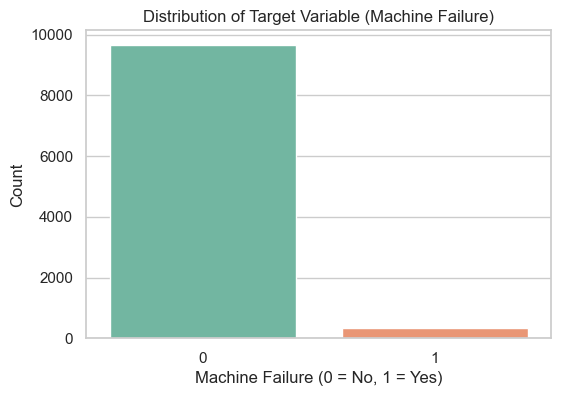

Percentage of failures in dataset: 3.39%


In [6]:
# Set visual style
sns.set_theme(style="whitegrid")

# 1. Visualise the distribution of the target variable
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='Machine failure', palette='Set2')
plt.title('Distribution of Target Variable (Machine Failure)')
plt.xlabel('Machine Failure (0 = No, 1 = Yes)')
plt.ylabel('Count')
plt.show()

# Calculate class imbalance
failure_rate = df['Machine failure'].mean() * 100
print(f"Percentage of failures in dataset: {failure_rate:.2f}%")

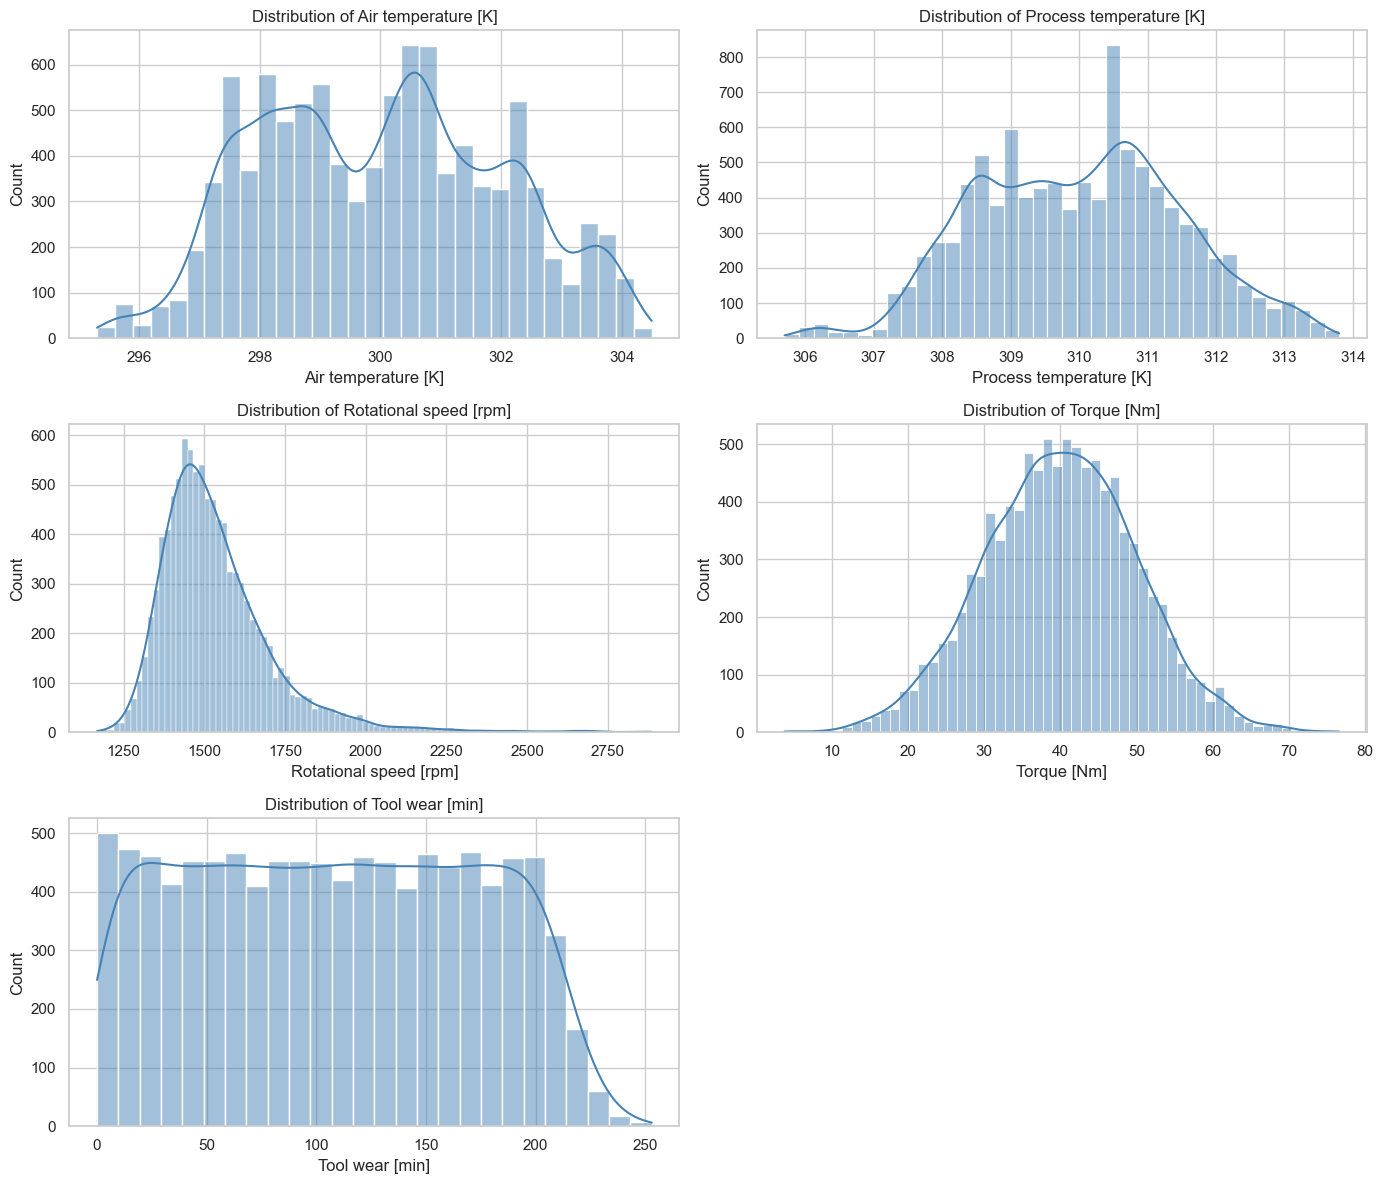

C:\Users\oshal\AppData\Local\Temp\ipykernel_3600\230618896.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Machine failure', y='Tool wear [min]', ax=axes[0], palette='Set2')
C:\Users\oshal\AppData\Local\Temp\ipykernel_3600\230618896.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Machine failure', y='Torque [Nm]', ax=axes[1], palette='Set2')
C:\Users\oshal\AppData\Local\Temp\ipykernel_3600\230618896.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Machine failure', y='Rotational speed [rpm]',

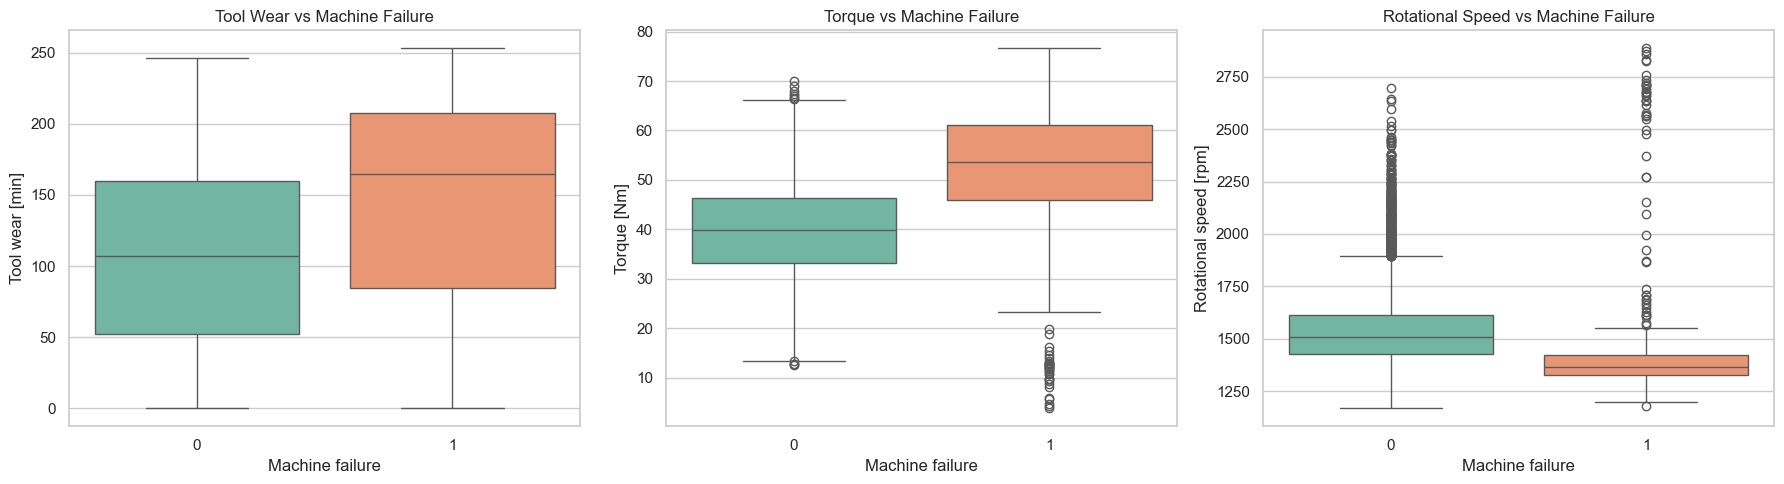

In [7]:
# 2. Plot distributions of numerical features
numerical_features = ['Air temperature [K]', 'Process temperature [K]', 
                    'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]']

fig, axes = plt.subplots(3, 2, figsize=(14, 12))
axes = axes.flatten()

for i, col in enumerate(numerical_features):
    sns.histplot(df[col], kde=True, ax=axes[i], color='steelblue')
    axes[i].set_title(f'Distribution of {col}')

# Remove the empty 6th subplot
fig.delaxes(axes[5])
plt.tight_layout()
plt.show()

# 3. Bivariate plots (Feature vs Target)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: Tool wear vs Machine Failure
sns.boxplot(data=df, x='Machine failure', y='Tool wear [min]', ax=axes[0], palette='Set2')
axes[0].set_title('Tool Wear vs Machine Failure')

# Plot 2: Torque vs Machine Failure
sns.boxplot(data=df, x='Machine failure', y='Torque [Nm]', ax=axes[1], palette='Set2')
axes[1].set_title('Torque vs Machine Failure')

# Plot 3: Rotational speed vs Machine Failure
sns.boxplot(data=df, x='Machine failure', y='Rotational speed [rpm]', ax=axes[2], palette='Set2')
axes[2].set_title('Rotational Speed vs Machine Failure')

plt.tight_layout()
plt.show()

3. EDA Patterns & Business Significance

Pattern 1: High Tool Wear Drives Failures

Observation: The boxplot shows failed machines have a significantly higher median and overall spread for tool wear compared to normal operations.

Business Significance: The IDSS can prevent breakdowns by enforcing a strict, automated tool-replacement threshold before wear reaches these critical upper limits.

Pattern 2: Extreme Torque Variance

Observation: Normal machines operate within a tight torque range. In contrast, failures occur at extreme high or low torque values, shown by a much wider boxplot spread.

Business Significance: The system must monitor for abnormal torque fluctuations—not just maximum limits—to catch early signs of motor or structural stress.

Pattern 3: Rotational Speed Anomalies

Observation: Normal rotational speeds cluster tightly together. When machines fail, the speed distribution skews, showing a lower median alongside extreme high-speed outliers.

Business Significance: By detecting sudden speed drops or abnormal spikes, production planners can halt operations before expensive internal components suffer catastrophic damage.

phase 2

In [8]:
import numpy as np

# Drop non-predictive identifier columns
if 'UDI' in df.columns and 'Product ID' in df.columns:
    df = df.drop(['UDI', 'Product ID'], axis=1)

# Function to cap outliers at the 1st and 99th percentiles
def cap_outliers(series):
    lower_limit = series.quantile(0.01)
    upper_limit = series.quantile(0.99)
    return np.clip(series, lower_limit, upper_limit)

# Apply capping to variables with extreme variance
df['Rotational speed [rpm]'] = cap_outliers(df['Rotational speed [rpm]'])
df['Torque [Nm]'] = cap_outliers(df['Torque [Nm]'])

print("Data Quality steps completed. Shape:", df.shape)

Data Quality steps completed. Shape: (10000, 13)


In [9]:
# 1. Temperature Difference
df['Temp_Diff'] = df['Process temperature [K]'] - df['Air temperature [K]']

# 2. Power Approximation
df['Power_Approx'] = df['Rotational speed [rpm]'] * df['Torque [Nm]']

# 3. Strain Index
df['Strain_Index'] = df['Tool wear [min]'] * df['Torque [Nm]']

print("Engineered features created successfully.")
display(df[['Temp_Diff', 'Power_Approx', 'Strain_Index']].head())

Engineered features created successfully.


,Temp_Diff,Power_Approx,Strain_Index
0,10.5,66382.8,0.0
1,10.5,65190.4,138.9
2,10.4,74001.2,247.0
3,10.4,56603.5,276.5
4,10.5,56320.0,360.0


In [10]:
# Ordinal encoding mapping
quality_mapping = {'L': 0, 'M': 1, 'H': 2}

# Apply mapping (handling potential previously created columns from Phase 1)
if 'Type' in df.columns:
    df['Type'] = df['Type'].map(quality_mapping)
elif 'Type_Ordinal' in df.columns:
    df['Type'] = df['Type_Ordinal']
    df = df.drop('Type_Ordinal', axis=1)

print("Categorical encoding applied.")
print(df['Type'].value_counts())

Categorical encoding applied.
Type
0    6000
1    2997
2    1003
Name: count, dtype: int64


In [11]:
from sklearn.preprocessing import StandardScaler

# Define features to scale (everything except target variables and encoded categorical)
target_cols = ['Machine failure', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF']
numerical_cols = [col for col in df.columns if col not in target_cols and col != 'Type']

# Initialize and apply StandardScaler
scaler = StandardScaler()
df[numerical_cols] = scaler.fit_transform(df[numerical_cols])

print("Scaling complete. Summary of scaled features:")
display(df[numerical_cols].describe().round(3))

Scaling complete. Summary of scaled features:


,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Type_Ordinal,Temp_Diff,Power_Approx,Strain_Index
count,10000.000,10000.000,10000.000,10000.000,10000.000,10000.000,10000.000,10000.000,10000.000
mean,-0.000,0.000,0.000,-0.000,0.000,-0.000,-0.000,-0.000,0.000
std,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000
min,-2.352,-2.902,-1.566,-2.379,-1.696,-0.745,-2.398,-2.605,-1.532
25%,-0.852,-0.813,-0.680,-0.692,-0.863,-0.745,-0.700,-0.687,-0.831
50%,0.048,0.064,-0.201,0.013,0.001,-0.745,-0.200,-0.009,-0.108
75%,0.747,0.738,0.451,0.697,0.849,0.744,0.998,0.691,0.697
max,2.247,2.557,3.900,2.332,2.279,2.234,2.097,3.088,3.687


In [12]:
from sklearn.model_selection import train_test_split

# Define Features (X) and Target (y)
# We predict 'Machine failure'. The specific failure modes (TWF, HDF, etc.) represent data leakage if included in X.
X = df.drop(columns=target_cols)
y = df['Machine failure']

# 80/20 Stratified Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42, 
    stratify=y
)

# Save to CSV files
X_train.to_csv('X_train.csv', index=False)
X_test.to_csv('X_test.csv', index=False)
y_train.to_csv('y_train.csv', index=False)
y_test.to_csv('y_test.csv', index=False)

print(f"Data successfully split and saved!")
print(f"X_train shape: {X_train.shape} | y_train shape: {y_train.shape}")
print(f"X_test shape: {X_test.shape}   | y_test shape: {y_test.shape}")

Data successfully split and saved!
X_train shape: (8000, 10) | y_train shape: (8000,)
X_test shape: (2000, 10)   | y_test shape: (2000,)


## Step 6: Data Dictionary

| Feature | Type | Range (Scaled/Encoded) | Meaning |
| :--- | :--- | :--- | :--- |
| **Type** | Ordinal Int | 0, 1, 2 | Product quality variant (L=0, M=1, H=2). |
| **Air temperature [K]** | Continuous | Scaled (Mean=0, SD=1) | The ambient air temperature in the manufacturing facility. |
| **Process temperature [K]** | Continuous | Scaled (Mean=0, SD=1) | The temperature of the process directly at the machine. |
| **Rotational speed [rpm]** | Continuous | Scaled (Mean=0, SD=1) | The calculated actual rotational speed of the machine. Capped at 1% and 99%. |
| **Torque [Nm]** | Continuous | Scaled (Mean=0, SD=1) | The torque applied by the machine. Capped at 1% and 99%. |
| **Tool wear [min]** | Continuous | Scaled (Mean=0, SD=1) | The duration the current tool has been in use. |
| **Temp_Diff** | Continuous | Scaled (Mean=0, SD=1) | *[Engineered]* Process temp minus Air temp. Captures thermal strain. |
| **Power_Approx** | Continuous | Scaled (Mean=0, SD=1) | *[Engineered]* Speed multiplied by Torque. Captures mechanical power stress. |
| **Strain_Index** | Continuous | Scaled (Mean=0, SD=1) | *[Engineered]* Tool wear multiplied by Torque. Captures force on degrading tools. |
| **Machine failure** | Binary Int | 0 or 1 | **[Target Variable]** Label indicating if the machine failed (1) or not (0). |
| **TWF, HDF, PWF, OSF, RNF** | Binary Int | 0 or 1 | Specific machine failure modes (Tool wear, Heat Dissipation, Power, Overstrain, Random). *Excluded from X_train/X_test to prevent data leakage.* |